In [1]:
import jax.numpy as jnp
from utils import load_run_data
import matplotlib.pyplot as plt
lstd_config, lstd_metrics = load_run_data("cov_lstd_ts/deepsea_sweep/2026-01-10/cov_lstd_two_speed_N21", "DeepSea-bsuite", 'results')
net_config, net_metrics = load_run_data("cov_net_v/deepsea_sweep/2026-01-10/cov_net_v_N21", "DeepSea-bsuite", 'results')
net_metrics.keys()

dict_keys(['bonus_max', 'bonus_mean', 'bonus_std', 'discount', 'e_value_error', 'e_value_loss', 'entropy', 'feat_norm', 'i_value_error', 'i_value_loss', 'intrinsic_rew_mean', 'intrinsic_rew_std', 'intrinsic_v_mean', 'intrinsic_v_std', 'lambda_ret_mean', 'lambda_ret_std', 'mean_rew', 'pi_loss', 'ppo_loss', 'returned_discounted_episode_returns', 'returned_episode', 'returned_episode_lengths', 'returned_episode_returns', 'v_e', 'v_e_pred', 'v_i', 'v_i_pred'])

In [2]:
N = net_config['DEEPSEA_SIZE']
reachable_mask = jnp.tril(jnp.ones((N,N)))

### Analysis: 
0. Show the extrinsic value function
1. plot intrinsic and exitrinsic value and predictions thereof
2. plot the absolute value error at the starting state for each.

## Extrinsic Value functions

In [3]:
# import matplotlib.pyplot as plt
# import numpy as np

# # 1. Extract Data
# initial_grid = metrics['v_e'][0][0]   # Shape (N, N)
# final_grid   = metrics['v_e'][0][5]  # Shape (N, N)

# # 2. Determine common color scale (Global Min/Max)
# vmin = min(initial_grid.min(), final_grid.min())
# vmax = max(initial_grid.max(), final_grid.max())

# # 3. Setup Plot
# fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# # --- Plot Initial ---
# im1 = axes[0].matshow(initial_grid, vmin=vmin, vmax=vmax, cmap='viridis')
# axes[0].set_title(f"Initial Policy Value\n(Start State Val: {initial_grid[0,0]:.4f})", y=1.1)

# # --- Plot Final ---
# im2 = axes[1].matshow(final_grid, vmin=vmin, vmax=vmax, cmap='viridis')
# axes[1].set_title(f"Final Policy Value\n(Start State Val: {final_grid[0,0]:.4f})", y=1.1)

# # --- Shared Colorbar ---
# # We anchor the colorbar to both axes so it sits nicely on the right
# cbar = fig.colorbar(im1, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
# cbar.set_label('True Extrinsic Value')

# # Optional: Add text annotations if grid is small (N <= 10)
# if initial_grid.shape[0] <= 10:
#     for (i, j), z in np.ndenumerate(initial_grid):
#         axes[0].text(j, i, f'{z:.2f}', ha='center', va='center', color='w' if z < vmax/2 else 'k', fontsize=8)
#     for (i, j), z in np.ndenumerate(final_grid):
#         axes[1].text(j, i, f'{z:.2f}', ha='center', va='center', color='w' if z < vmax/2 else 'k', fontsize=8)

# plt.show()

In [4]:
# # 1. Extract Data
# initial_grid = metrics['v_i'][0][0]   # Shape (N, N)
# final_grid   = metrics['v_i'][0][5]  # Shape (N, N)

# # 2. Determine common color scale (Global Min/Max)
# vmin = min(initial_grid.min(), final_grid.min())
# vmax = max(initial_grid.max(), final_grid.max())

# # 3. Setup Plot
# fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# # --- Plot Initial ---
# im1 = axes[0].matshow(initial_grid, vmin=vmin, vmax=vmax, cmap='viridis')
# axes[0].set_title(f"Initial Policy Intrinsic Value\n(Start State Val: {initial_grid[0,0]:.4f})", y=1.1)

# # --- Plot Final ---
# im2 = axes[1].matshow(final_grid, vmin=vmin, vmax=vmax, cmap='viridis')
# axes[1].set_title(f"Final Policy Intrinsic Value\n(Start State Val: {final_grid[0,0]:.4f})", y=1.1)

# # --- Shared Colorbar ---
# # We anchor the colorbar to both axes so it sits nicely on the right
# cbar = fig.colorbar(im1, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
# cbar.set_label('True Intrinsic Value')

# # Optional: Add text annotations if grid is small (N <= 10)
# if initial_grid.shape[0] <= 10:
#     for (i, j), z in np.ndenumerate(initial_grid):
#         axes[0].text(j, i, f'{z:.2f}', ha='center', va='center', color='w' if z < vmax/2 else 'k', fontsize=8)
#     for (i, j), z in np.ndenumerate(final_grid):
#         axes[1].text(j, i, f'{z:.2f}', ha='center', va='center', color='w' if z < vmax/2 else 'k', fontsize=8)

# plt.show()

In [5]:
# # 1. Extract Data
# initial_grid = metrics['v_i_pred'][0][0]   # Shape (N, N)
# final_grid   = metrics['v_i_pred'][0][5]  # Shape (N, N)

# # 2. Determine common color scale (Global Min/Max)
# vmin = min(initial_grid.min(), final_grid.min())
# vmax = max(initial_grid.max(), final_grid.max())

# # 3. Setup Plot
# fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# # --- Plot Initial ---
# im1 = axes[0].matshow(initial_grid, vmin=vmin, vmax=vmax, cmap='viridis')
# axes[0].set_title(f"Initial Policy Intrinsic Value\n(Start State Val: {initial_grid[0,0]:.4f})", y=1.1)

# # --- Plot Final ---
# im2 = axes[1].matshow(final_grid, vmin=vmin, vmax=vmax, cmap='viridis')
# axes[1].set_title(f"Final Policy Intrinsic Value\n(Start State Val: {final_grid[0,0]:.4f})", y=1.1)

# # --- Shared Colorbar ---
# # We anchor the colorbar to both axes so it sits nicely on the right
# cbar = fig.colorbar(im1, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
# cbar.set_label('True Intrinsic Value')

# # Optional: Add text annotations if grid is small (N <= 10)
# if initial_grid.shape[0] <= 10:
#     for (i, j), z in np.ndenumerate(initial_grid):
#         axes[0].text(j, i, f'{z:.2f}', ha='center', va='center', color='w' if z < vmax/2 else 'k', fontsize=8)
#     for (i, j), z in np.ndenumerate(final_grid):
#         axes[1].text(j, i, f'{z:.2f}', ha='center', va='center', color='w' if z < vmax/2 else 'k', fontsize=8)

# plt.show()

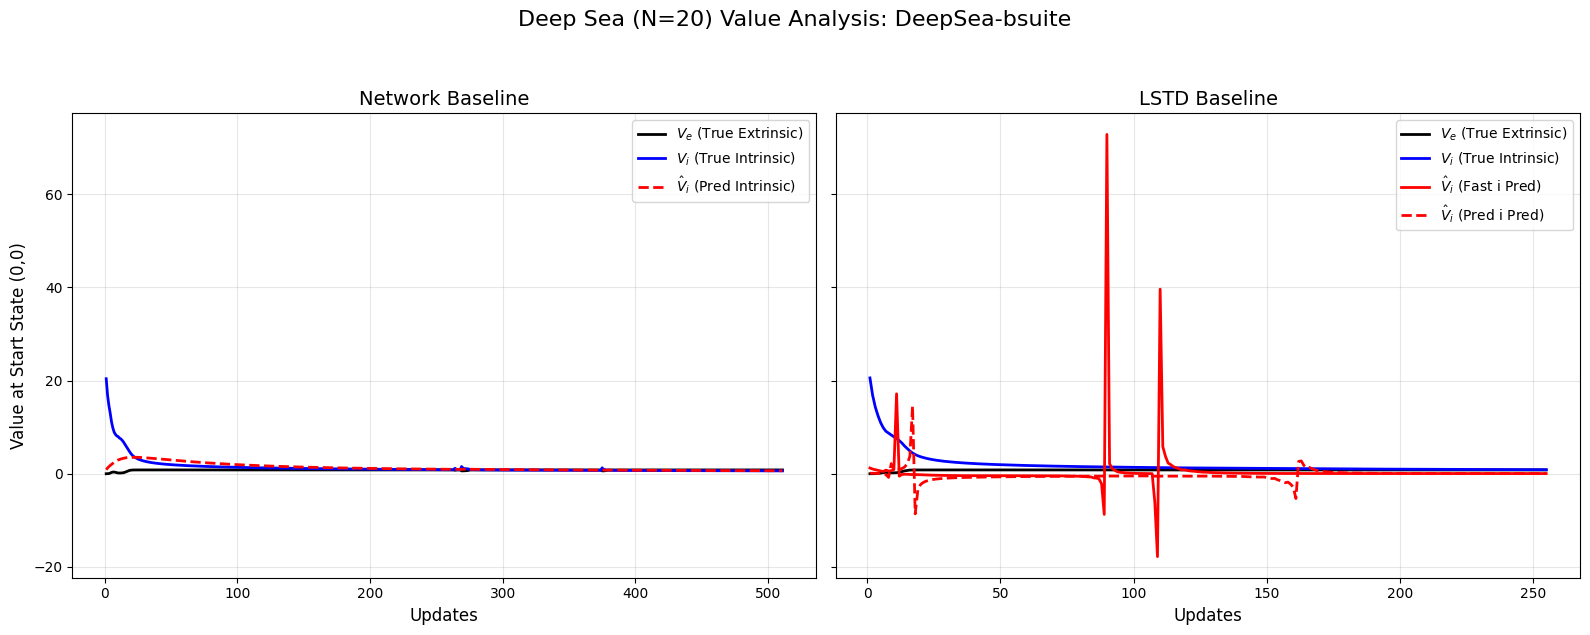

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def extract_start_state_curve(metric_data):
    """
    Helper to extract time-series for the start state (0,0).
    Handles (Time, N, N) or (Seeds, Time, N, N) shapes.
    """
    data = np.array(metric_data)
    
    # Handle Multi-seed: (Seeds, Time, ...) -> Mean over seeds -> (Time, ...)
    if data.ndim == 4: 
        data = data.mean(axis=0)
        
    # Handle Grid: (Time, N, N) -> Slice start state -> (Time,)
    if data.ndim == 3:
        return data[:, 0, 0]
    
    # Fallback if already scalar/1D
    return data

# --- Setup Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
run_data = [
    ("Network Baseline", net_metrics, axes[0]),
    ("LSTD Baseline", lstd_metrics, axes[1])
]

# Metrics to plot and their visual styles
# Keys match your dict: 'v_e', 'v_i_pred', 'v_i'
plot_config = [
    {"key": "v_e",      "label": r"$V_e$ (True Extrinsic)", "color": "black", "style": "-"},
    {"key": "v_i",      "label": r"$V_i$ (True Intrinsic)", "color": "blue",  "style": "-"},
    {"key": "v_i_pred", "label": r"$\hat{V}_i$ (Pred Intrinsic)", "color": "red",   "style": "--"},
    {"key": "fast_v_i_pred", "label": r"$\hat{V}_i$ (Fast i Pred)", "color": "red",   "style": "-"},
    {"key": "slow_v_i_pred", "label": r"$\hat{V}_i$ (Pred i Pred)", "color": "red",   "style": "--"},
]

# --- Loop over Runs ---
for title, metrics, ax in run_data:
    for item in plot_config:
        key = item["key"]
        if key in metrics:
            # Extract curve
            curve = extract_start_state_curve(metrics[key])
            
            # Plot
            # Slicing [1:] removes the pre-training initialization spike if present
            steps = np.arange(len(curve))[1:]
            values = curve[1:]
            
            ax.plot(steps, values, label=item["label"], color=item["color"], linestyle=item["style"], linewidth=2)
    
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Updates", fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

# --- Final Adjustments ---
axes[0].set_ylabel("Value at Start State (0,0)", fontsize=12)
plt.suptitle(f"Deep Sea (N=20) Value Analysis: {net_config['ENV_NAME']}", y=1.05, fontsize=16)
plt.tight_layout()
plt.show()

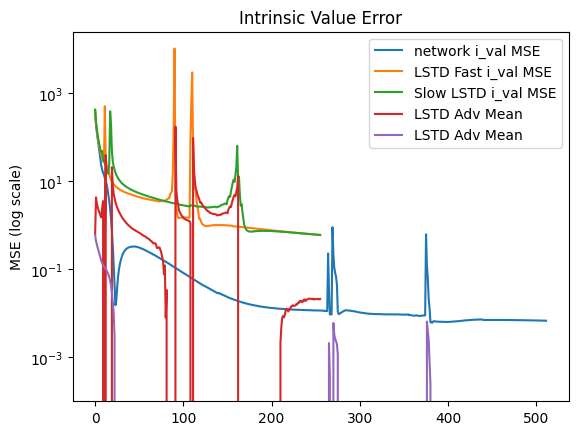

In [19]:
plt.plot(net_metrics['i_value_error'].mean(0), label = 'network i_val MSE')
plt.plot(lstd_metrics['fast_i_value_error'].mean(0), label = 'LSTD Fast i_val MSE')
plt.plot(lstd_metrics['slow_i_value_error'].mean(0), label = 'Slow LSTD i_val MSE')
plt.plot(lstd_metrics['bonus_mean'].mean(0), label = 'LSTD Adv Mean')
plt.plot(net_metrics['bonus_mean'].mean(0), label = 'LSTD Adv Mean')
plt.legend()
plt.title('Intrinsic Value Error')
plt.ylabel('MSE (log scale)')
plt.yscale('log')

In [20]:
lstd_metrics['v_i'].shape

(4, 256, 21, 21)

In [21]:
lstd_metrics.keys()

dict_keys(['bonus_max', 'bonus_mean', 'bonus_std', 'discount', 'e_value_error', 'fast_i_value_error', 'fast_v_i_pred', 'feat_norm', 'intrinsic_rew_mean', 'intrinsic_rew_std', 'intrinsic_rew_terminal', 'lambda_ret_mean', 'lambda_ret_std', 'mean_rew', 'ppo_loss', 'returned_discounted_episode_returns', 'returned_episode', 'returned_episode_lengths', 'returned_episode_returns', 'ri_grid', 'rnd_loss', 'slow_i_value_error', 'slow_v_i_pred', 'v_e', 'v_e_pred', 'v_i'])

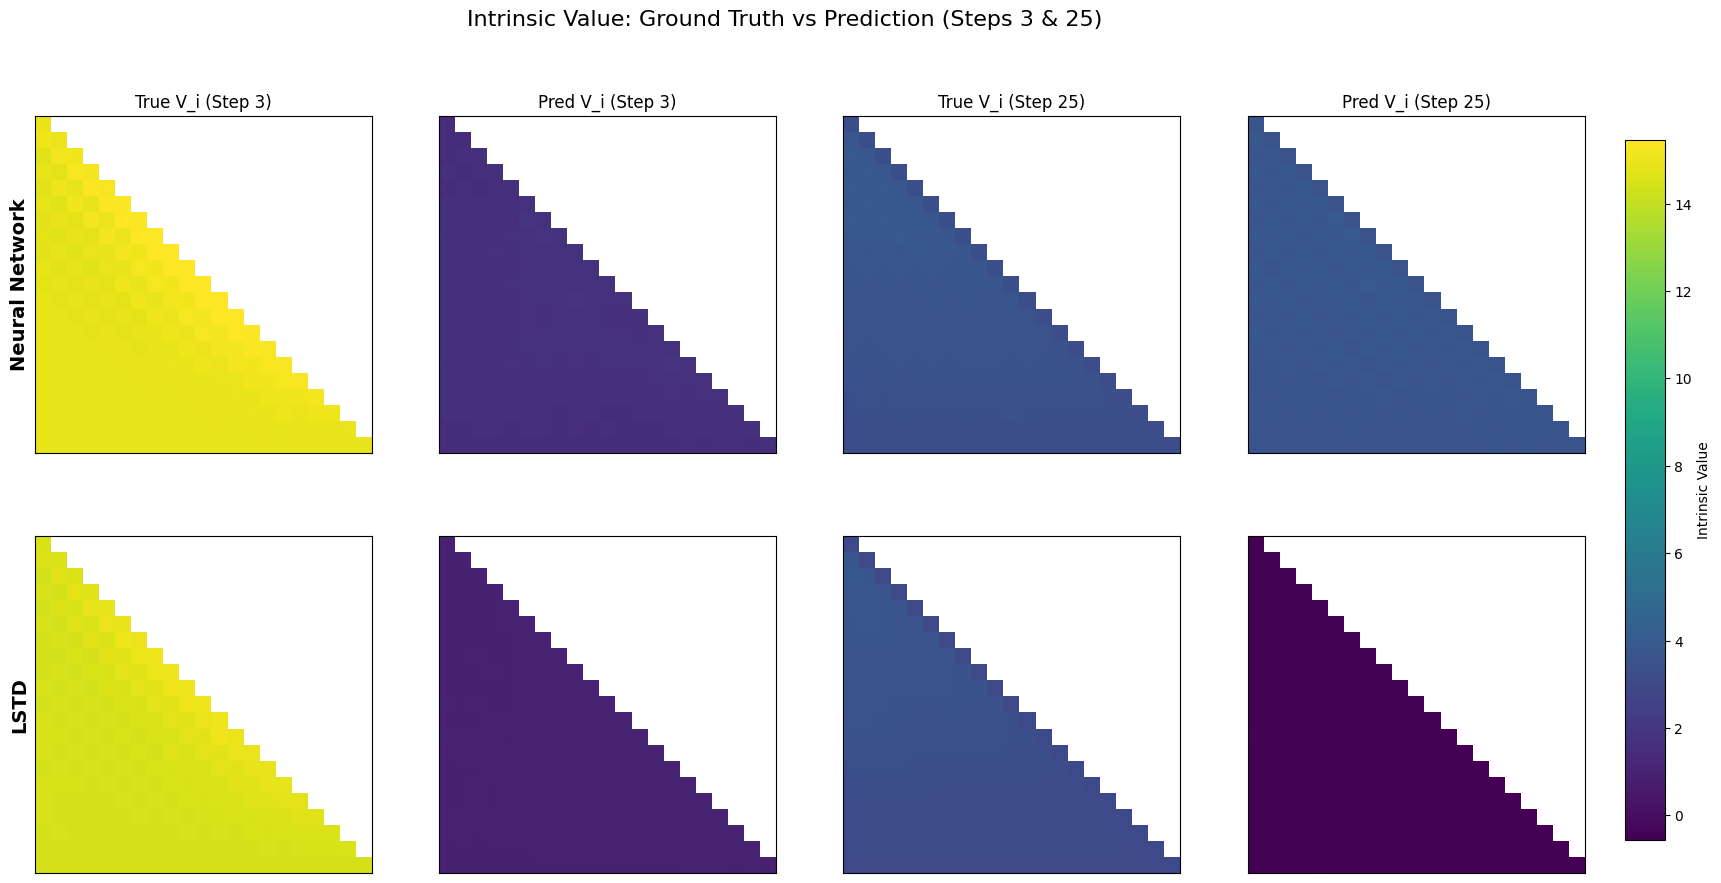

In [22]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
import numpy as np

# 1. Setup & Masking
N = net_config['DEEPSEA_SIZE']
reachable_mask = np.tril(np.ones((N, N)))

def get_masked_grid(metric_array, step_idx, seed_idx=0):
    """Extracts grid, applies mask, and sets non-reachable to NaN for plotting."""
    grid = metric_array[seed_idx, step_idx]
    # Apply mask: Keep reachable, set others to NaN
    masked_grid = np.where(reachable_mask == 1, grid, np.nan)
    return masked_grid

# 2. Extract Data for Plotting
# Steps to visualize
t1, t2 = 3, 25

# Row 1: Network Data
net_true_t1 = get_masked_grid(net_metrics['v_i'], t1)
net_pred_t1 = get_masked_grid(net_metrics['v_i_pred'], t1)
net_true_t2 = get_masked_grid(net_metrics['v_i'], t2)
net_pred_t2 = get_masked_grid(net_metrics['v_i_pred'], t2)

# Row 2: LSTD Data
lstd_true_t1 = get_masked_grid(lstd_metrics['v_i'], t1)
lstd_pred_t1 = get_masked_grid(lstd_metrics['fast_v_i_pred'], t1) # Using fast_v_i_pred
lstd_true_t2 = get_masked_grid(lstd_metrics['v_i'], t2)
lstd_pred_t2 = get_masked_grid(lstd_metrics['fast_v_i_pred'], t2)

# 3. Compute Global Limits for Common Color Scale
all_grids = [
    net_true_t1, net_pred_t1, net_true_t2, net_pred_t2,
    lstd_true_t1, lstd_pred_t1, lstd_true_t2, lstd_pred_t2
]
# Use nanmin/nanmax to ignore the masked regions
vmin = np.nanmin(all_grids)
vmax = np.nanmax(all_grids)

# 4. Plotting
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Row 1: Neural Network
rows = ["Neural Network", "LSTD"]
data_matrix = [
    [net_true_t1, net_pred_t1, net_true_t2, net_pred_t2],
    [lstd_true_t1, lstd_pred_t1, lstd_true_t2, lstd_pred_t2]
]

titles = [
    f"True V_i (Step {t1})", f"Pred V_i (Step {t1})", 
    f"True V_i (Step {t2})", f"Pred V_i (Step {t2})"
]

for row_idx in range(2):
    for col_idx in range(4):
        ax = axes[row_idx, col_idx]
        grid = data_matrix[row_idx][col_idx]
        
        im = ax.imshow(grid, cmap='viridis', vmin=vmin, vmax=vmax)
        
        # Formatting
        if col_idx == 0:
            ax.set_ylabel(rows[row_idx], fontsize=14, fontweight='bold')
        
        if row_idx == 0:
            ax.set_title(titles[col_idx], fontsize=12)
            
        ax.set_xticks([])
        ax.set_yticks([])

# Add a single Colorbar for the whole figure
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) # [left, bottom, width, height]
fig.colorbar(im, cax=cbar_ax, label='Intrinsic Value')

plt.suptitle(f"Intrinsic Value: Ground Truth vs Prediction (Steps {t1} & {t2})", fontsize=16)
plt.show()

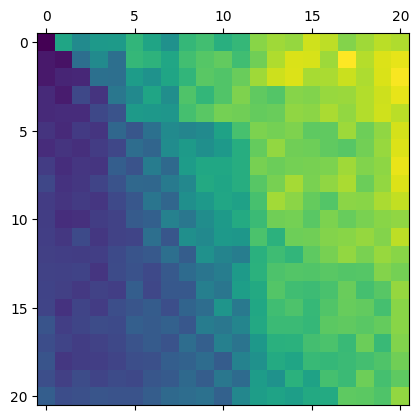

In [23]:
plt.matshow(lstd_metrics['ri_grid'][0][1])

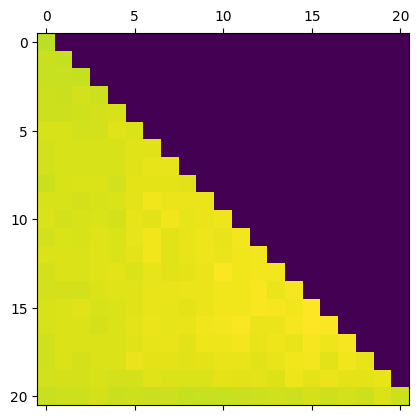

In [25]:
plt.matshow(lstd_metrics['fast_v_i_pred'][0][5]* reachable_mask)

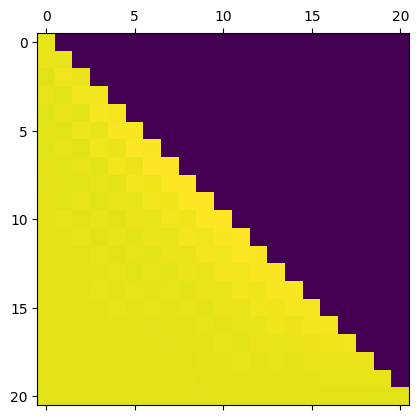

In [26]:
plt.matshow(lstd_metrics['v_i'][0][3]* reachable_mask) 

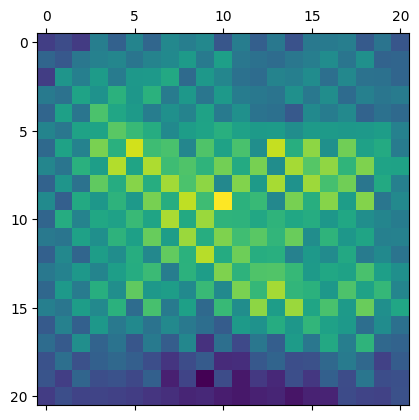

In [27]:
plt.matshow(net_metrics['v_i_pred'][0][5])

In [28]:
lstd_metrics['returned_episode_returns'][1][0:50]

Array([-0.00425537, -0.00581485, -0.00687314, -0.00773577,  0.00718169,
        0.01313105,  0.07124733,  0.230733  ,  0.26902357,  0.15026437,
        0.09453613,  0.10912108,  0.09394567,  0.07783924,  0.13770577,
        0.2244386 ,  0.4623468 ,  0.88947594,  0.98487556,  0.99      ,
        0.99      ,  0.99      ,  0.98487556,  0.99      ,  0.99      ,
        0.99      ,  0.99      ,  0.99      ,  0.98487556,  0.99      ,
        0.99      ,  0.99      ,  0.99      ,  0.99      ,  0.99      ,
        0.99      ,  0.99      ,  0.99      ,  0.99      ,  0.99      ,
        0.99      ,  0.99      ,  0.99      ,  0.99      ,  0.98487556,
        0.99      ,  0.99      ,  0.99      ,  0.99      ,  0.99      ],      dtype=float32)

In [39]:
lstd_metrics['ri_grid'][1][10][21]

Array([0.12551701, 0.12753588, 0.12664284, 0.14008695, 0.13456434,
       0.12105843, 0.11567573, 0.13948944, 0.12228878, 0.12946072,
       0.1156148 , 0.12606427, 0.10368953, 0.11386798, 0.09801149,
       0.11074116, 0.09425028, 0.11614026, 0.09008601, 0.13919088,
       0.10605627], dtype=float32)

In [40]:
lstd_metrics['fast_v_i_pred'][1][10][20]

Array([0.65903175, 0.64872044, 0.6537891 , 0.63967586, 0.6478704 ,
       0.6461152 , 0.6512438 , 0.6629865 , 0.671778  , 0.6410244 ,
       0.65248406, 0.6530301 , 0.6506913 , 0.6475762 , 0.6537927 ,
       0.6468462 , 0.6413265 , 0.64744514, 0.63389707, 0.6545436 ,
       0.6424788 ], dtype=float32)

In [42]:
lstd_metrics['v_i'][1][10][19]

Array([8.487025 , 8.486239 , 8.497845 , 8.492595 , 8.483911 , 8.479005 ,
       8.496578 , 8.480533 , 8.490569 , 8.476544 , 8.486197 , 8.465148 ,
       8.474964 , 8.458268 , 8.470685 , 8.454499 , 8.47552  , 8.4500885,
       8.498731 , 8.4657955, 8.466681 ], dtype=float32)